In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
scores_df = pd.read_csv("experiment_scores.csv", usecols=['difficulty', 'LLM', 'N of Docs', 'Score (Joshna)', 'Score (Mami)', 'Score (Komal)', 'Type of error'])

In [4]:
jscore_df = pd.read_csv("experiment_scores.csv", usecols=['difficulty', 'LLM', 'N of Docs', 'Score (Joshna)', 'Type of error'])
mscore_df = pd.read_csv("experiment_scores.csv", usecols=['difficulty', 'LLM', 'N of Docs', 'Score (Mami)', 'Type of error'])
kscore_df = pd.read_csv("experiment_scores.csv", usecols=['difficulty', 'LLM', 'N of Docs', 'Score (Komal)', 'Type of error'])

In [5]:
jscore_df['Score'] = jscore_df.pop('Score (Joshna)')
mscore_df['Score'] = mscore_df.pop('Score (Mami)')
kscore_df['Score'] = kscore_df.pop('Score (Komal)')

In [6]:
long_df = pd.concat([jscore_df, mscore_df, kscore_df])

In [6]:
long_df

,difficulty,LLM,N of Docs,Type of error,Score
0,Easy,Codestral,0,syntactical,2.0
1,Easy,Codellama:latest,0,syntactical,1.0
2,Easy,Codellama:13b,0,syntactical,2.0
3,Easy,mistral-small,0,syntactical,2.0
4,Easy,codegemma:7b,0,syntactical,2.0
...,...,...,...,...,...
67,Hard,mistral-small,4,logical,3.0
68,Hard,codegemma:7b,4,logical,3.0
69,Hard,phi4,4,syntactical + hallucination + logical,2.0
70,Hard,deepseek-coder-v2,4,logical,2.0


In [7]:
codestral_df = long_df[long_df['LLM'] == 'Codestral']
codellamal_df = long_df[long_df['LLM'] == 'Codellama:latest']
codellama13b_df = long_df[long_df['LLM'] == 'Codellama:13b']
mistral_df = long_df[long_df['LLM'] == 'mistral-small']
codegemma_df = long_df[long_df['LLM'] == 'codegemma:7b']
phi_df = long_df[long_df['LLM'] == 'phi4']
deepseek_df = long_df[long_df['LLM'] == 'deepseek-coder-v2']
gpt_df = long_df[long_df['LLM'] == 'gpt-4o-mini']

In [81]:
gpt_df.groupby('Score').count().max()

difficulty       6
LLM              6
N of Docs        6
Type of error    5
dtype: int64

In [11]:
def make_hist(df, pos, model):
    plt.subplot(3, 3, pos)
    sns.histplot(x=df["Score"], bins=5)
    plt.title(f'Performance Score Distribution for {model}', size=15, loc='left')
    plt.xlabel('Score', size=16)
    plt.ylabel('Frequency')
    plt.xticks(np.arange(0, 5, 1), size=14)
    plt.yticks(np.arange(0, 9, 2), size=14)
    plt.grid(True, axis='y', linestyle='--', linewidth=0.5, alpha=0.7, color='black')
    sns.despine()

In [12]:
codestral_df = codestral_df.reset_index(drop=True)
codellamal_df = codellamal_df.reset_index(drop=True)
codellama13b_df = codellama13b_df.reset_index(drop=True)
codegemma_df = codegemma_df.reset_index(drop=True)
mistral_df = mistral_df.reset_index(drop=True)
phi_df = phi_df.reset_index(drop=True)
deepseek_df = deepseek_df.reset_index(drop=True)
gpt_df = gpt_df.reset_index(drop=True)

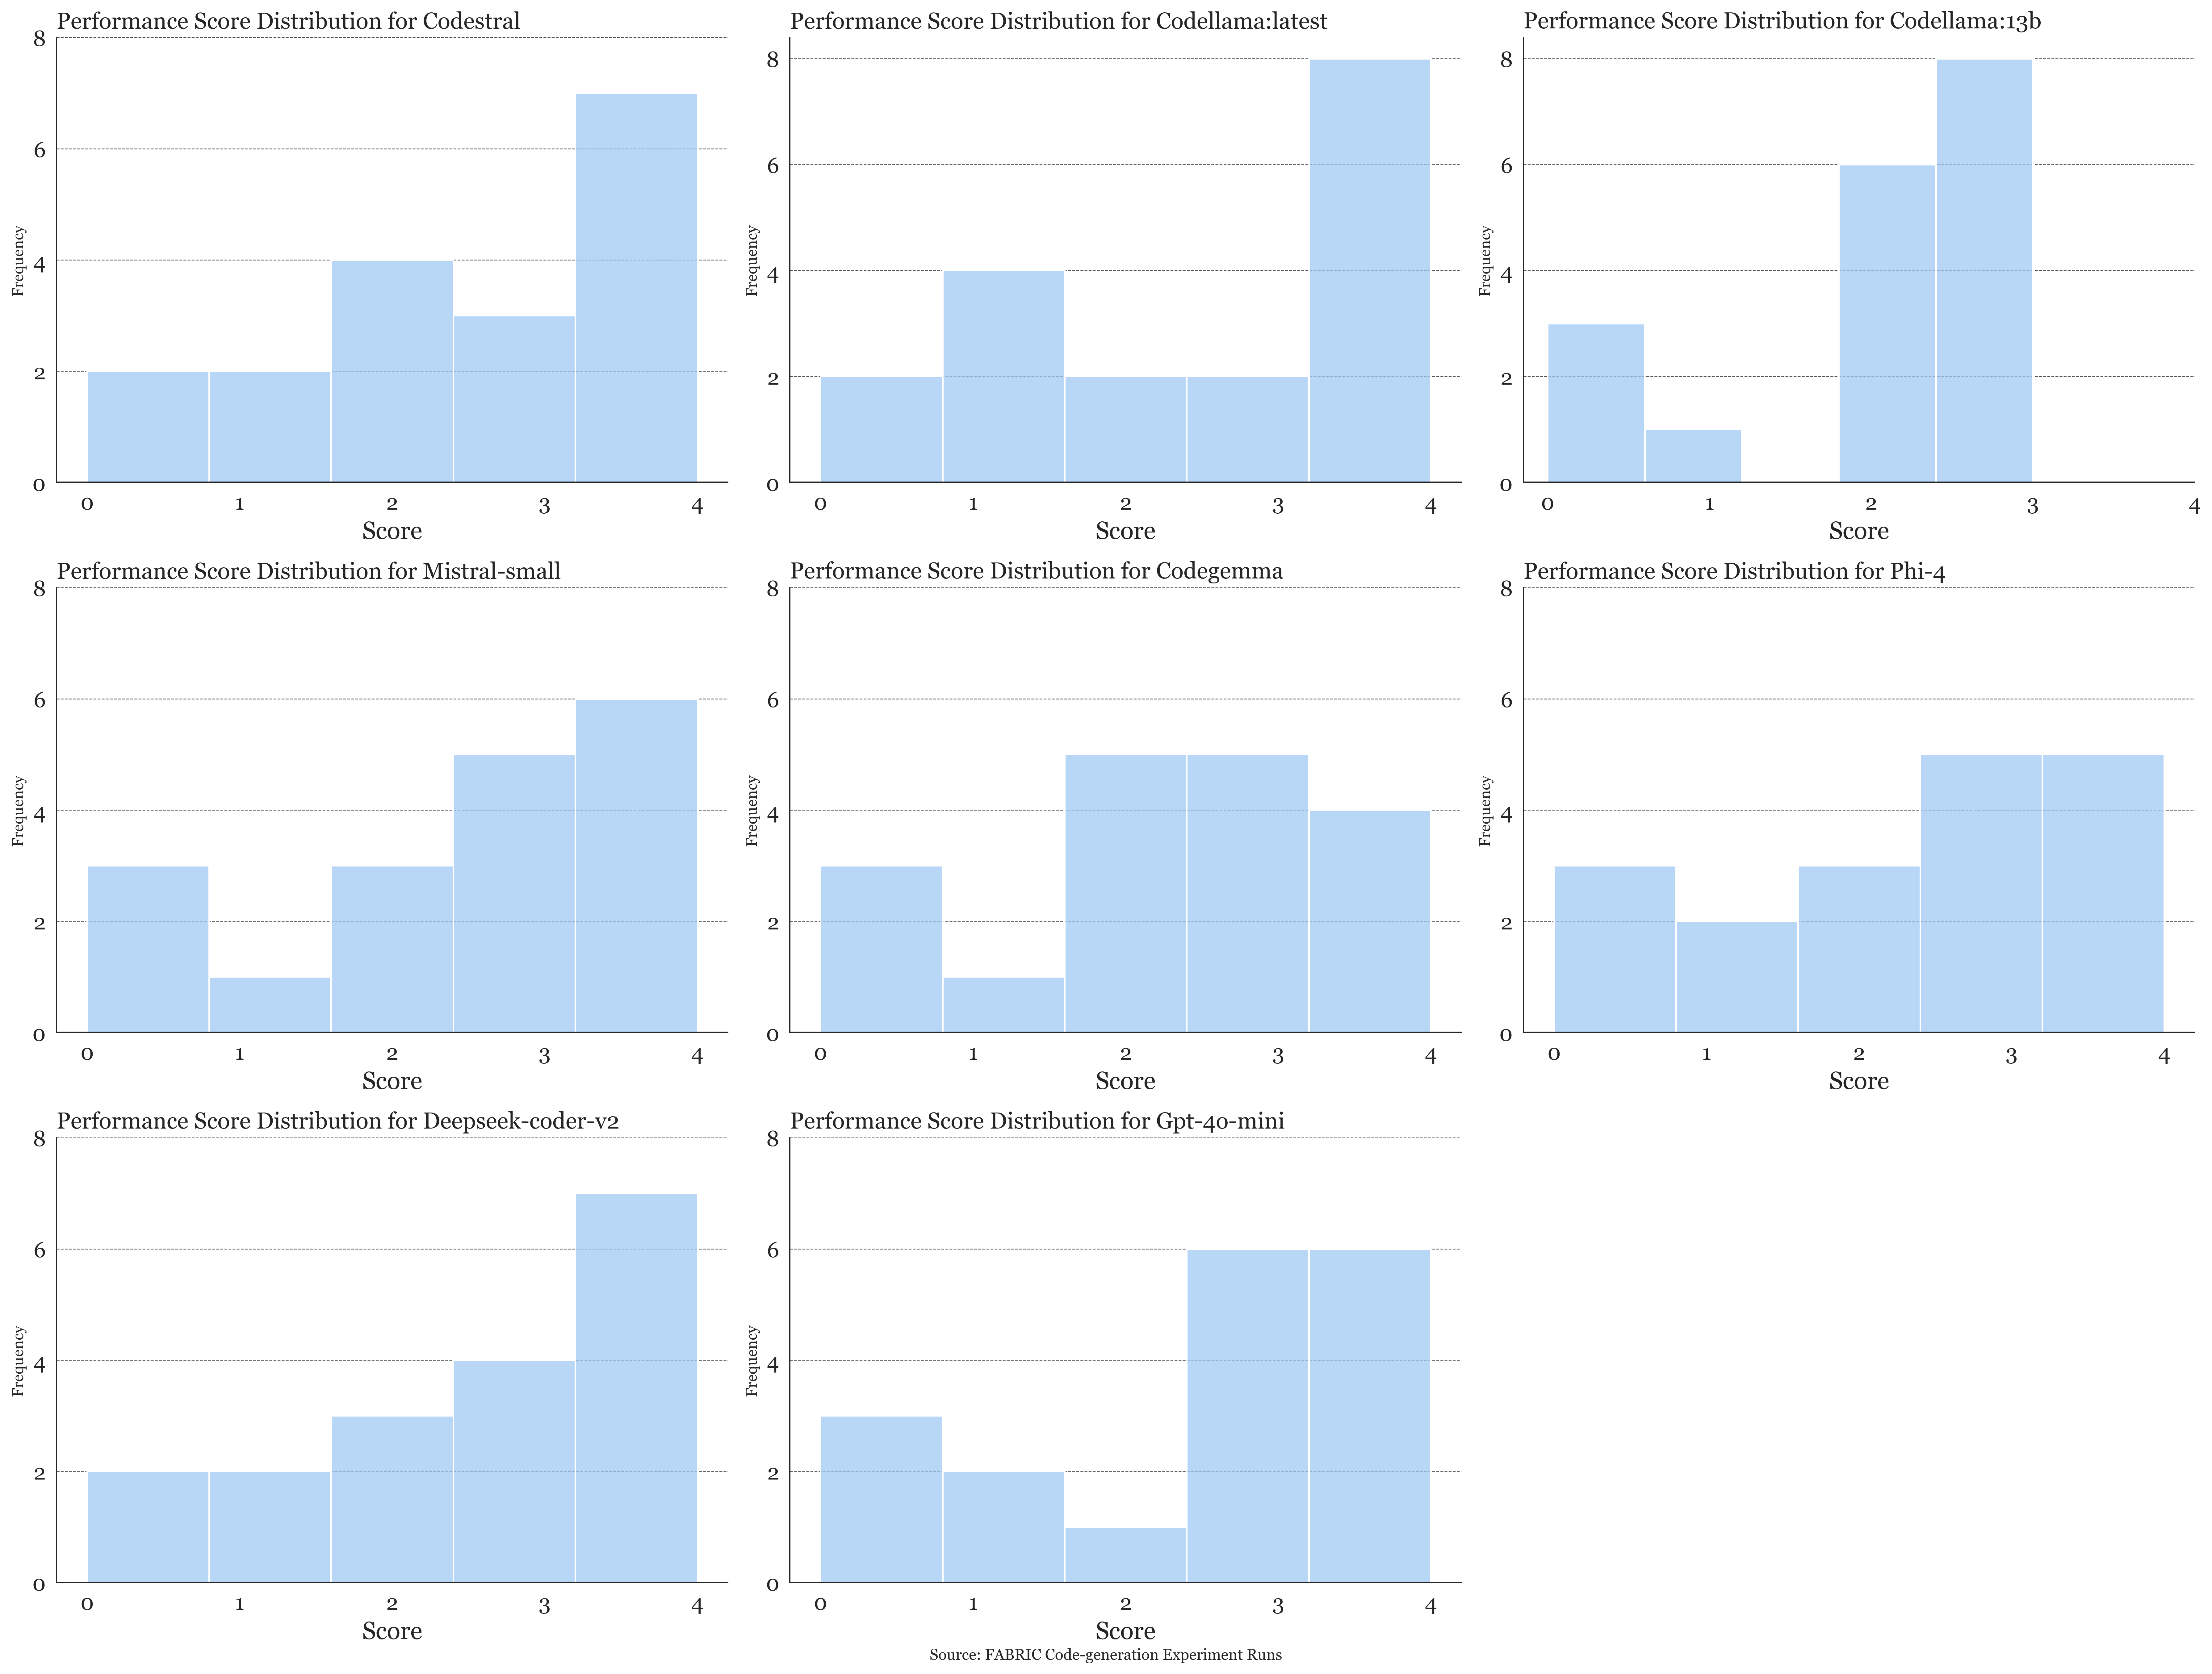

In [13]:
# plt.style.use(matplotx.styles.duftify(matplotx.styles.nord))
plt.figure(figsize=(20,15))
sns.set_style("white")
sns.set_palette("pastel")
plt.rcParams["font.family"] = "Georgia"
plt.rcParams['figure.dpi'] = 360

make_hist(codestral_df, 1, 'Codestral')
make_hist(codellamal_df, 2, 'Codellama:latest')
make_hist(codellama13b_df, 3, 'Codellama:13b')
make_hist(mistral_df, 4, 'Mistral-small')
make_hist(codegemma_df, 5, 'Codegemma')
make_hist(phi_df, 6, 'Phi-4')
make_hist(deepseek_df, 7, 'Deepseek-coder-v2')
make_hist(gpt_df, 8, 'Gpt-4o-mini')

plt.figtext(0.5, 0.001, "Source: FABRIC Code-generation Experiment Runs", ha='center', fontsize=10)
plt.tight_layout()

In [14]:
def make_kde(df, pos, model):
    plt.subplot(3, 3, pos)
    sns.kdeplot(data=df, x="Score", shade=True)
    plt.title(f'Performance Score Distribution for {model}', size=15, loc='left')
    plt.xlabel('Score', size=20)
    plt.ylabel('Frequency')
    plt.xticks(np.arange(0, 5, 1), size=14)
    # plt.yticks(np.arange(0, 9, 2), size=14)
    sns.despine()

/var/folders/xg/53pcsq_s2p51msld09_vyrzw0000gn/T/ipykernel_84748/1236782725.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df, x="Score", shade=True)
/var/folders/xg/53pcsq_s2p51msld09_vyrzw0000gn/T/ipykernel_84748/1236782725.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df, x="Score", shade=True)
/var/folders/xg/53pcsq_s2p51msld09_vyrzw0000gn/T/ipykernel_84748/1236782725.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df, x="Score", shade=True)
/var/folders/xg/53pcsq_s2p51msld09_vyrzw0000gn/T/ipykernel_84748/1236782725.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; set

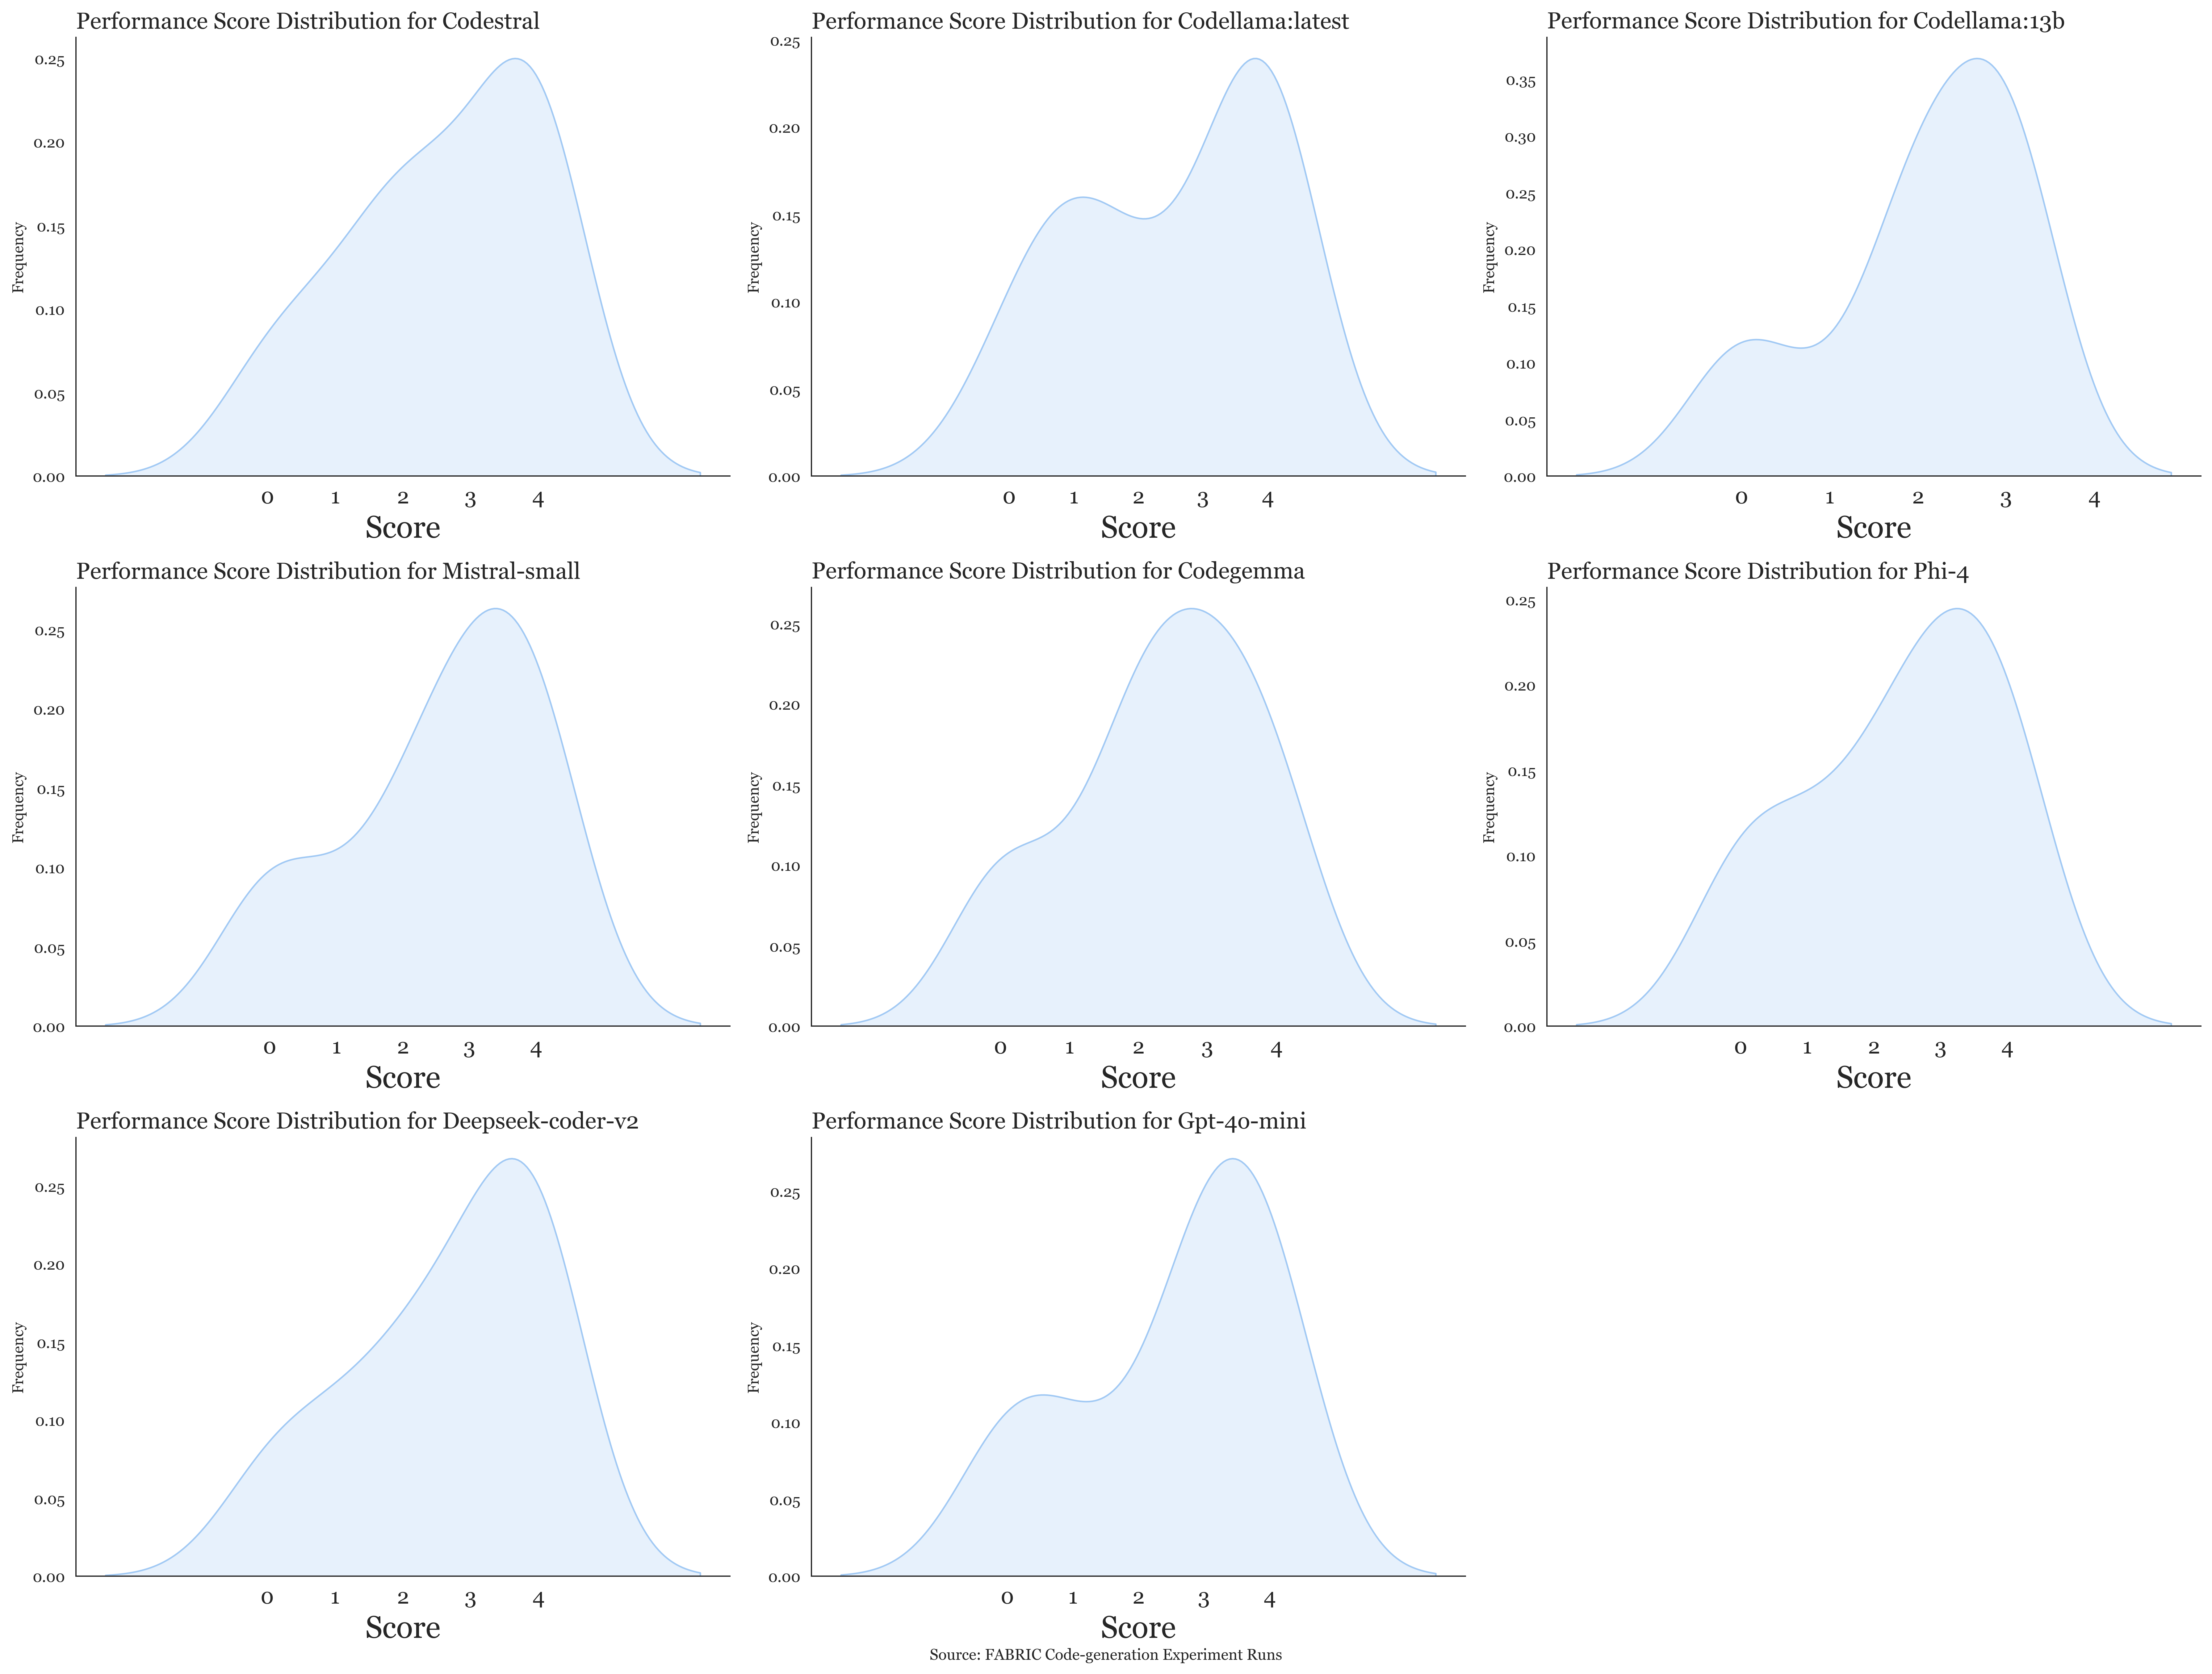

In [15]:
plt.figure(figsize=(20,15))
# sns.set_style("white")
# sns.set_palette("pastel")
# plt.style.use('rose-pine-moon')
plt.rcParams["font.family"] = "Georgia"
plt.rcParams['figure.dpi'] = 360

make_kde(codestral_df, 1, 'Codestral')
make_kde(codellamal_df, 2, 'Codellama:latest')
make_kde(codellama13b_df, 3, 'Codellama:13b')
make_kde(mistral_df, 4, 'Mistral-small')
make_kde(codegemma_df, 5, 'Codegemma')
make_kde(phi_df, 6, 'Phi-4')
make_kde(deepseek_df, 7, 'Deepseek-coder-v2')
make_kde(gpt_df, 8, 'Gpt-4o-mini')

plt.figtext(0.5, 0.001, "Source: FABRIC Code-generation Experiment Runs", ha='center', fontsize=10)
plt.tight_layout()

In [3]:
scores_df.head()

,difficulty,LLM,N of Docs,Score (Joshna),Score (Mami),Score (Komal),Type of error
0,Easy,Codestral,0,2,2.0,NaN,syntactical
1,Easy,Codellama:latest,0,1,1.0,NaN,syntactical
2,Easy,Codellama:13b,0,2,2.0,NaN,syntactical
3,Easy,mistral-small,0,2,2.0,NaN,syntactical
4,Easy,codegemma:7b,0,2,2.0,NaN,syntactical


In [5]:
# Separate the easy, medium, hard scores
easy_df = scores_df[scores_df['difficulty'] == 'Easy']
medium_df = scores_df[scores_df['difficulty'] == 'Medium']
hard_df = scores_df[scores_df['difficulty'] == 'Hard']

In [ ]:
# Drop Komal's score because she didn't score these
easy_df = easy_df.drop('Score (Komal)', axis=1)
medium_df = medium_df.drop('Score (Komal)', axis=1)

In [8]:
# Drop Mami's score because she didn't score these
hard_df = hard_df.drop('Score (Mami)', axis=1)

In [13]:
# Since there are no missing scores, ready to get average score
easy_df['Average Score'] = (easy_df['Score (Joshna)'] + easy_df['Score (Mami)']) / 2
medium_df['Average Score'] = (medium_df['Score (Joshna)'] + medium_df['Score (Mami)']) / 2
hard_df['Average Score'] = (hard_df['Score (Joshna)'] + hard_df['Score (Komal)']) / 2

In [14]:
# Take a look at the datasets
easy_df.head()

,difficulty,LLM,N of Docs,Score (Joshna),Score (Mami),Type of error,Average Score
0,Easy,Codestral,0,2,2.0,syntactical,2.0
1,Easy,Codellama:latest,0,1,1.0,syntactical,1.0
2,Easy,Codellama:13b,0,2,2.0,syntactical,2.0
3,Easy,mistral-small,0,2,2.0,syntactical,2.0
4,Easy,codegemma:7b,0,2,2.0,syntactical,2.0


In [15]:
medium_df.head()

,difficulty,LLM,N of Docs,Score (Joshna),Score (Mami),Type of error,Average Score
24,Medium,Codestral,0,1,1.0,syntactical + logical,1.0
25,Medium,Codellama:latest,0,1,1.0,syntactical + logical,1.0
26,Medium,Codellama:13b,0,1,0.0,syntactical + logical,0.5
27,Medium,mistral-small,0,1,0.0,syntactical + logical,0.5
28,Medium,codegemma:7b,0,1,0.0,syntactical + logical,0.5


In [16]:
hard_df.head()

,difficulty,LLM,N of Docs,Score (Joshna),Score (Komal),Type of error,Average Score
48,Hard,Codestral,0,0,0.0,syntactical+logical +hallucination,0.0
49,Hard,Codellama:latest,0,0,0.0,syntactical+logical +hallucination,0.0
50,Hard,Codellama:13b,0,0,0.0,syntactical+logical +hallucination,0.0
51,Hard,mistral-small,0,0,0.0,syntactical+logical +hallucination,0.0
52,Hard,codegemma:7b,0,0,0.0,syntactical+logical +hallucination,0.0


In [17]:
# Change score type to int 
easy_df['Average Score'] = easy_df['Average Score'].astype(int)
medium_df['Average Score'] = medium_df['Average Score'].astype(int)
hard_df['Average Score'] = hard_df['Average Score'].astype(int)

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
combined_df = pd.concat([easy_df, medium_df, hard_df], ignore_index=True)